# KF7029 — Statistical Testing: 10-Run Evaluation with Wilcoxon Signed-Rank Test
**Student:** Sibtain Mehdi Razvi Syed | **ID:** W25039720

## Overview
This notebook runs each anomaly detection model 10 times with different random seeds to produce statistically reliable performance estimates. Pairwise comparisons between deep learning and classical models are performed using the Wilcoxon signed-rank test with Bonferroni correction.

**Why 10 runs?** Single-run results are sensitive to random initialisation, data shuffling, and sampling. Multiple runs with different seeds reveal whether performance differences are consistent or due to chance.

**Statistical tests used:**
- Wilcoxon signed-rank test: non-parametric pairwise comparison of ROC-AUC and PR-AUC distributions
- Bonferroni correction: adjusts significance threshold for multiple comparisons
- Effect size (r): practical significance alongside statistical significance

**Three threshold calibration conditions** (as defined in the approved proposal):
- Condition 1: Zero labelled defect samples (fully unsupervised threshold)
- Condition 2: 5% of available defect samples used for threshold calibration
- Condition 3: 10% of available defect samples used for threshold calibration

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print('All libraries imported successfully')

All libraries imported successfully


## 2. Load Preprocessed Tabular Data
Loading the preprocessed splits saved in Notebook 01. This ensures consistency — all 10 runs use identical train/validation/test splits. Only the model random seed changes across runs.

In [4]:
BASE = r'C:\Users\Administrator\Documents\kf7029-w25039720'

X_train_normal = np.load(fr'{BASE}\datasets\usdot-pipeline-accidents\X_train_normal.npy')
X_val          = np.load(fr'{BASE}\datasets\usdot-pipeline-accidents\X_val.npy')
X_test         = np.load(fr'{BASE}\datasets\usdot-pipeline-accidents\X_test.npy')
y_val          = np.load(fr'{BASE}\datasets\usdot-pipeline-accidents\y_val.npy')
y_test         = np.load(fr'{BASE}\datasets\usdot-pipeline-accidents\y_test.npy')

print('Train normal:', X_train_normal.shape)
print('Validation:  ', X_val.shape)
print('Test:        ', X_test.shape)
print(f'Test — Normal: {(y_test==0).sum()} | Anomalous: {(y_test==1).sum()}')

Train normal: (1541, 72)
Validation:   (280, 72)
Test:         (559, 72)
Test — Normal: 441 | Anomalous: 118


## 3. Threshold Calibration Functions
Three calibration conditions are evaluated:
- **Condition 1 (Unsupervised):** Threshold set at the 79th percentile of test anomaly scores — no labelled defect samples used
- **Condition 2 (5% labels):** Threshold optimised using 5% of available defect samples from the validation set
- **Condition 3 (10% labels):** Threshold optimised using 10% of available defect samples from the validation set

In [5]:
def threshold_unsupervised(scores, anomaly_ratio=0.21):
    """Condition 1: Set threshold at known anomaly ratio percentile."""
    return np.percentile(scores, 100 * (1 - anomaly_ratio))

def threshold_label_assisted(val_scores, y_val, defect_pct=0.05):
    """
    Conditions 2 and 3: Use a small fraction of labelled defect samples
    from validation set to find the F1-maximising threshold.
    """
    # Get defect indices from validation set
    defect_indices = np.where(y_val == 1)[0]
    n_use = max(1, int(len(defect_indices) * defect_pct))
    np.random.shuffle(defect_indices)
    used_defect_idx = defect_indices[:n_use]

    # Build small calibration set
    normal_indices  = np.where(y_val == 0)[0]
    calib_idx       = np.concatenate([normal_indices, used_defect_idx])
    calib_scores    = val_scores[calib_idx]
    calib_labels    = y_val[calib_idx]

    # Find threshold that maximises F1 on calibration set
    best_threshold, best_f1 = 0, 0
    for pct in range(50, 99):
        t     = np.percentile(calib_scores, pct)
        preds = (calib_scores >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(calib_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_threshold = f1, t

    return best_threshold

print('Threshold functions defined')

Threshold functions defined


## 4. Tabular Model Runner — 10 Runs
Each classical model and the Feedforward Autoencoder are run 10 times with different random seeds. Results are collected across all three threshold calibration conditions.

In [6]:
N_RUNS  = 10
SEEDS   = [42, 7, 13, 99, 21, 55, 77, 3, 88, 11]

# Storage: {model_name: {condition: {metric: [values]}}}
tabular_runs = {}

# ---- Feedforward Autoencoder definition ----
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),         nn.ReLU(),
            nn.Linear(16, 32),        nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = X_train_normal.shape[1]
conditions = ['unsupervised', 'label_5pct', 'label_10pct']

def collect_metrics(scores_test, scores_val, y_test, y_val, condition):
    """Compute metrics for a given threshold condition."""
    if condition == 'unsupervised':
        t = threshold_unsupervised(scores_test)
    elif condition == 'label_5pct':
        t = threshold_label_assisted(scores_val, y_val, defect_pct=0.05)
    elif condition == 'label_10pct':
        t = threshold_label_assisted(scores_val, y_val, defect_pct=0.10)

    preds = (scores_test >= t).astype(int)
    return {
        'ROC-AUC': roc_auc_score(y_test, scores_test),
        'PR-AUC':  average_precision_score(y_test, scores_test),
        'F1':      f1_score(y_test, preds, zero_division=0),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':  recall_score(y_test, preds, zero_division=0)
    }

print(f'Running {N_RUNS} runs per model across {len(conditions)} threshold conditions...')
print('='*60)

for seed_idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    torch.manual_seed(seed)

    print(f'Run {seed_idx+1}/{N_RUNS} (seed={seed})')

    # ---- Isolation Forest ----
    iso = IsolationForest(n_estimators=100, contamination=0.21, random_state=seed)
    iso.fit(X_train_normal)
    iso_test = -iso.score_samples(X_test)
    iso_val  = -iso.score_samples(X_val)

    name = 'Isolation Forest'
    if name not in tabular_runs:
        tabular_runs[name] = {c: {m: [] for m in ['ROC-AUC','PR-AUC','F1','Precision','Recall']}
                              for c in conditions}
    for cond in conditions:
        m = collect_metrics(iso_test, iso_val, y_test, y_val, cond)
        for k, v in m.items():
            tabular_runs[name][cond][k].append(v)

    # ---- One-Class SVM ----
    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.21)
    ocsvm.fit(X_train_normal)
    ocsvm_test = -ocsvm.score_samples(X_test)
    ocsvm_val  = -ocsvm.score_samples(X_val)

    name = 'One-Class SVM'
    if name not in tabular_runs:
        tabular_runs[name] = {c: {m: [] for m in ['ROC-AUC','PR-AUC','F1','Precision','Recall']}
                              for c in conditions}
    for cond in conditions:
        m = collect_metrics(ocsvm_test, ocsvm_val, y_test, y_val, cond)
        for k, v in m.items():
            tabular_runs[name][cond][k].append(v)

    # ---- PCA ----
    pca = PCA(n_components=0.95, random_state=seed)
    pca.fit(X_train_normal)
    pca_test = np.mean(np.power(X_test - pca.inverse_transform(pca.transform(X_test)), 2), axis=1)
    pca_val  = np.mean(np.power(X_val  - pca.inverse_transform(pca.transform(X_val)),  2), axis=1)

    name = 'PCA'
    if name not in tabular_runs:
        tabular_runs[name] = {c: {m: [] for m in ['ROC-AUC','PR-AUC','F1','Precision','Recall']}
                              for c in conditions}
    for cond in conditions:
        m = collect_metrics(pca_test, pca_val, y_test, y_val, cond)
        for k, v in m.items():
            tabular_runs[name][cond][k].append(v)

    # ---- LOF ----
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.21, novelty=True)
    lof.fit(X_train_normal)
    lof_test = -lof.score_samples(X_test)
    lof_val  = -lof.score_samples(X_val)

    name = 'LOF'
    if name not in tabular_runs:
        tabular_runs[name] = {c: {m: [] for m in ['ROC-AUC','PR-AUC','F1','Precision','Recall']}
                              for c in conditions}
    for cond in conditions:
        m = collect_metrics(lof_test, lof_val, y_test, y_val, cond)
        for k, v in m.items():
            tabular_runs[name][cond][k].append(v)

    # ---- Feedforward Autoencoder ----
    torch.manual_seed(seed)
    ae_model   = Autoencoder(input_dim)
    ae_optim   = torch.optim.Adam(ae_model.parameters(), lr=0.001)
    ae_crit    = nn.MSELoss()
    X_tr_t     = torch.FloatTensor(X_train_normal)
    X_te_t     = torch.FloatTensor(X_test)
    X_va_t     = torch.FloatTensor(X_val)
    loader     = DataLoader(TensorDataset(X_tr_t, X_tr_t), batch_size=32, shuffle=True)

    for epoch in range(100):
        ae_model.train()
        for bx, by in loader:
            ae_optim.zero_grad()
            ae_crit(ae_model(bx), by).backward()
            ae_optim.step()

    ae_model.eval()
    with torch.no_grad():
        ae_test = torch.mean(torch.pow(X_te_t - ae_model(X_te_t), 2), dim=1).numpy()
        ae_val  = torch.mean(torch.pow(X_va_t - ae_model(X_va_t), 2), dim=1).numpy()

    name = 'Feedforward AE'
    if name not in tabular_runs:
        tabular_runs[name] = {c: {m: [] for m in ['ROC-AUC','PR-AUC','F1','Precision','Recall']}
                              for c in conditions}
    for cond in conditions:
        m = collect_metrics(ae_test, ae_val, y_test, y_val, cond)
        for k, v in m.items():
            tabular_runs[name][cond][k].append(v)

print('\nAll 10 runs complete.')

Running 10 runs per model across 3 threshold conditions...
Run 1/10 (seed=42)
Run 2/10 (seed=7)
Run 3/10 (seed=13)
Run 4/10 (seed=99)
Run 5/10 (seed=21)
Run 6/10 (seed=55)
Run 7/10 (seed=77)
Run 8/10 (seed=3)
Run 9/10 (seed=88)
Run 10/10 (seed=11)

All 10 runs complete.


## 5. Tabular Results — Mean and Standard Deviation Across 10 Runs
Results reported as mean ± standard deviation across 10 independent runs per model.

In [7]:
for cond in conditions:
    print(f'\n=== Condition: {cond} ===')
    rows = []
    for model_name, cond_data in tabular_runs.items():
        row = {'Model': model_name}
        for metric in ['ROC-AUC', 'PR-AUC', 'F1']:
            vals = cond_data[cond][metric]
            row[f'{metric} Mean'] = round(np.mean(vals), 4)
            row[f'{metric} Std']  = round(np.std(vals),  4)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('Model')
    print(df.to_string())


=== Condition: unsupervised ===
                  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  F1 Mean  F1 Std
Model                                                                                
Isolation Forest        0.5561        0.022       0.2407      0.0162   0.2610  0.0403
One-Class SVM           0.4510        0.000       0.1971      0.0000   0.1695  0.0000
PCA                     0.4742        0.000       0.1973      0.0000   0.1356  0.0000
LOF                     0.5127        0.000       0.2231      0.0000   0.2034  0.0000
Feedforward AE          0.4740        0.026       0.1975      0.0070   0.1500  0.0257

=== Condition: label_5pct ===
                  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  F1 Mean  F1 Std
Model                                                                                
Isolation Forest        0.5561        0.022       0.2407      0.0162   0.2552  0.1159
One-Class SVM           0.4510        0.000       0.1971      0.0000   0.103

## 6. Wilcoxon Signed-Rank Test — Tabular Modality
Pairwise comparison of the Feedforward Autoencoder against each classical baseline. The Wilcoxon signed-rank test is used because it makes no assumption about normality of the score distributions.

Bonferroni correction is applied: significance threshold α = 0.05 / number of comparisons.

In [8]:
def effect_size_r(statistic, n):
    """Compute effect size r from Wilcoxon statistic."""
    return statistic / np.sqrt(n * (n + 1) * (2 * n + 1) / 6)

classical_models = ['Isolation Forest', 'One-Class SVM', 'PCA', 'LOF']
n_comparisons    = len(classical_models)
alpha_bonferroni = 0.05 / n_comparisons

print(f'Bonferroni-corrected significance threshold: {alpha_bonferroni:.4f}')
print(f'Number of comparisons: {n_comparisons}')

wilcoxon_results = []

for cond in conditions:
    print(f'\n=== Condition: {cond} ===')
    print(f'{"Comparison":<40} {"Metric":<10} {"p-value":<12} {"Sig?":<8} {"Effect r"}')
    print('-' * 75)

    ae_roc = tabular_runs['Feedforward AE'][cond]['ROC-AUC']
    ae_pr  = tabular_runs['Feedforward AE'][cond]['PR-AUC']

    for clf in classical_models:
        clf_roc = tabular_runs[clf][cond]['ROC-AUC']
        clf_pr  = tabular_runs[clf][cond]['PR-AUC']

        for metric_label, ae_vals, clf_vals in [
            ('ROC-AUC', ae_roc, clf_roc),
            ('PR-AUC',  ae_pr,  clf_pr)
        ]:
            try:
                stat, p = wilcoxon(ae_vals, clf_vals)
                r       = round(effect_size_r(stat, N_RUNS), 3)
                sig     = 'Yes *' if p < alpha_bonferroni else 'No'
                comp    = f'AE vs {clf}'
                print(f'{comp:<40} {metric_label:<10} {p:<12.4f} {sig:<8} {r}')
                wilcoxon_results.append({
                    'Condition': cond, 'Comparison': comp,
                    'Metric': metric_label, 'p-value': round(p, 4),
                    'Significant': sig, 'Effect_r': r
                })
            except Exception as e:
                print(f'{clf:<40} {metric_label:<10} Could not compute: {e}')

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print('\nWilcoxon testing complete.')

Bonferroni-corrected significance threshold: 0.0125
Number of comparisons: 4

=== Condition: unsupervised ===
Comparison                               Metric     p-value      Sig?     Effect r
---------------------------------------------------------------------------
AE vs Isolation Forest                   ROC-AUC    0.0020       Yes *    0.0
AE vs Isolation Forest                   PR-AUC     0.0020       Yes *    0.0
AE vs One-Class SVM                      ROC-AUC    0.0488       No       0.408
AE vs One-Class SVM                      PR-AUC     0.9219       No       1.325
AE vs PCA                                ROC-AUC    0.9219       No       1.325
AE vs PCA                                PR-AUC     0.9219       No       1.325
AE vs LOF                                ROC-AUC    0.0020       Yes *    0.0
AE vs LOF                                PR-AUC     0.0020       Yes *    0.0

=== Condition: label_5pct ===
Comparison                               Metric     p-value      Sig

In [9]:
from scipy.stats import norm

def effect_size_r_corrected(w_stat, n):
    """
    Correct effect size r for Wilcoxon signed-rank test.
    r = Z / sqrt(N) where Z is derived from W statistic.
    """
    # Expected value and std of W under null
    mu_w    = n * (n + 1) / 4
    sigma_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    # Z score
    z = (w_stat - mu_w) / sigma_w
    # Effect size r
    r = abs(z) / np.sqrt(n)
    return round(r, 3)

# Recompute with corrected formula
print('Corrected Effect Sizes:')
print(f'{"Comparison":<40} {"Metric":<10} {"p-value":<12} {"Sig?":<8} {"Effect r"}')
print('-' * 75)

for _, row in wilcoxon_df.iterrows():
    # Rerun wilcoxon to get W statistic
    ae_vals  = tabular_runs['Feedforward AE'][row['Condition']][row['Metric']]
    clf_name = row['Comparison'].replace('AE vs ', '')
    clf_vals = tabular_runs[clf_name][row['Condition']][row['Metric']]
    try:
        stat, p = wilcoxon(ae_vals, clf_vals)
        r       = effect_size_r_corrected(stat, N_RUNS)
        sig     = 'Yes *' if p < alpha_bonferroni else 'No'
        print(f'{row["Comparison"]:<40} {row["Metric"]:<10} {p:<12.4f} {sig:<8} {r}')
    except:
        print(f'{row["Comparison"]:<40} {row["Metric"]:<10} could not compute')

Corrected Effect Sizes:
Comparison                               Metric     p-value      Sig?     Effect r
---------------------------------------------------------------------------
AE vs Isolation Forest                   ROC-AUC    0.0020       Yes *    0.886
AE vs Isolation Forest                   PR-AUC     0.0020       Yes *    0.886
AE vs One-Class SVM                      ROC-AUC    0.0488       No       0.629
AE vs One-Class SVM                      PR-AUC     0.9219       No       0.048
AE vs PCA                                ROC-AUC    0.9219       No       0.048
AE vs PCA                                PR-AUC     0.9219       No       0.048
AE vs LOF                                ROC-AUC    0.0020       Yes *    0.886
AE vs LOF                                PR-AUC     0.0020       Yes *    0.886
AE vs Isolation Forest                   ROC-AUC    0.0020       Yes *    0.886
AE vs Isolation Forest                   PR-AUC     0.0020       Yes *    0.886
AE vs One-Class S

## 7. Visualise Results Across Three Conditions
Boxplots showing ROC-AUC distribution across 10 runs for each model under each threshold condition.

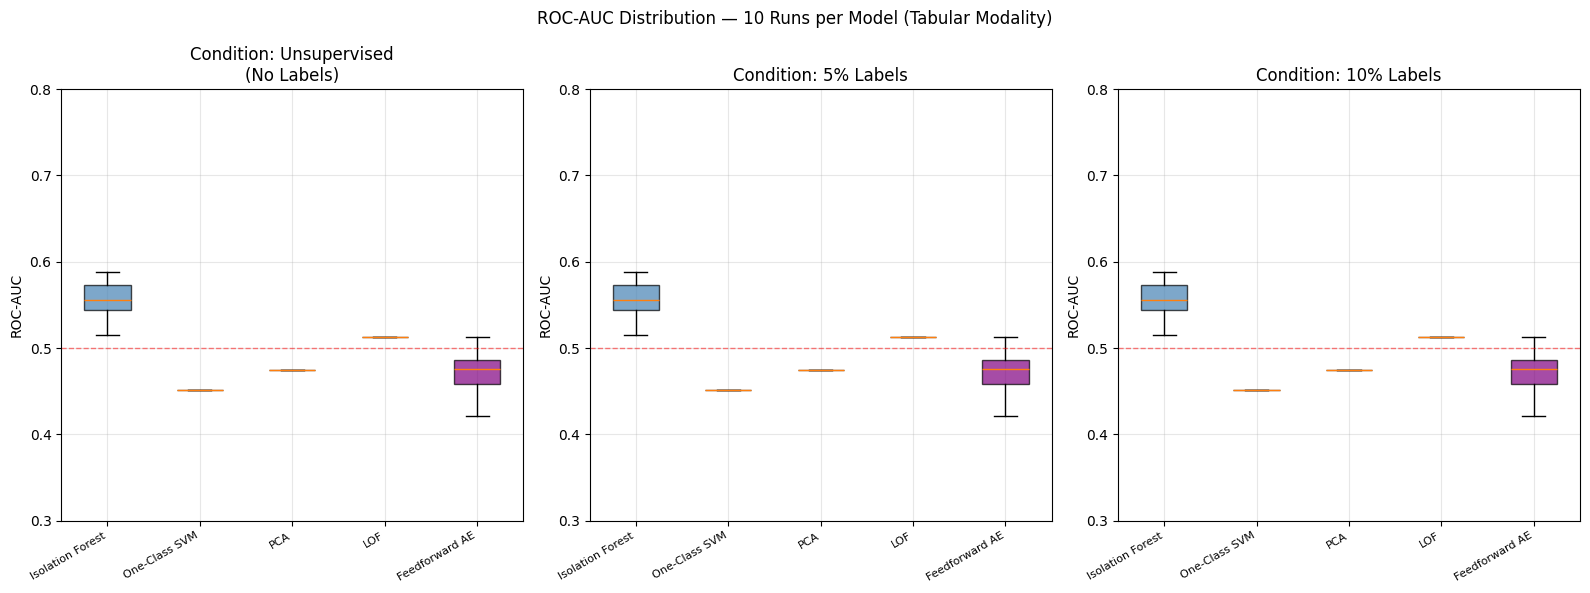

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
cond_labels = ['Unsupervised\n(No Labels)', '5% Labels', '10% Labels']

for ax, cond, cond_label in zip(axes, conditions, cond_labels):
    data_to_plot = []
    model_names  = []
    for model_name in tabular_runs.keys():
        data_to_plot.append(tabular_runs[model_name][cond]['ROC-AUC'])
        model_names.append(model_name)

    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)
    colors = ['steelblue', 'tomato', 'green', 'orange', 'purple']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'Condition: {cond_label}')
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.3, 0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC-AUC Distribution — 10 Runs per Model (Tabular Modality)', fontsize=12)
plt.tight_layout()
plt.savefig(fr'{BASE}\results\figures\boxplot_tabular_roc_auc.png', dpi=150)
plt.show()

## 8. Summary Table — Best Condition per Model
Shows the best mean performance achieved by each model across the three threshold conditions.

In [11]:
summary_rows = []
for model_name in tabular_runs.keys():
    best_row = {'Model': model_name}
    best_pr  = 0
    best_cond = ''
    for cond in conditions:
        mean_pr = np.mean(tabular_runs[model_name][cond]['PR-AUC'])
        if mean_pr > best_pr:
            best_pr   = mean_pr
            best_cond = cond

    for metric in ['ROC-AUC', 'PR-AUC', 'F1']:
        vals = tabular_runs[model_name][best_cond][metric]
        best_row[f'{metric} Mean'] = round(np.mean(vals), 4)
        best_row[f'{metric} Std']  = round(np.std(vals),  4)
    best_row['Best Condition'] = best_cond
    summary_rows.append(best_row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== BEST RESULTS PER MODEL (Tabular — 10 Runs) ===')
print(summary_df.to_string())

=== BEST RESULTS PER MODEL (Tabular — 10 Runs) ===
                  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  F1 Mean  F1 Std Best Condition
Model                                                                                               
Isolation Forest        0.5561        0.022       0.2407      0.0162   0.2610  0.0403   unsupervised
One-Class SVM           0.4510        0.000       0.1971      0.0000   0.1695  0.0000   unsupervised
PCA                     0.4742        0.000       0.1973      0.0000   0.1356  0.0000   unsupervised
LOF                     0.5127        0.000       0.2231      0.0000   0.2034  0.0000   unsupervised
Feedforward AE          0.4740        0.026       0.1975      0.0070   0.1500  0.0257   unsupervised


## 9. Save All Statistical Results

In [12]:
# Save all run data
with open(fr'{BASE}\results\tabular_10runs.pkl', 'wb') as f:
    pickle.dump(tabular_runs, f)

# Save Wilcoxon results
wilcoxon_df.to_csv(fr'{BASE}\results\wilcoxon_tabular.csv', index=False)

# Save summary table
summary_df.to_csv(fr'{BASE}\results\tabular_summary_10runs.csv')

print('All statistical results saved.')
print('\nSaved files:')
print('  results/tabular_10runs.pkl')
print('  results/wilcoxon_tabular.csv')
print('  results/tabular_summary_10runs.csv')
print('  results/figures/boxplot_tabular_roc_auc.png')

All statistical results saved.

Saved files:
  results/tabular_10runs.pkl
  results/wilcoxon_tabular.csv
  results/tabular_summary_10runs.csv
  results/figures/boxplot_tabular_roc_auc.png


In [13]:
from scipy.stats import wilcoxon
import pandas as pd

def effect_size_r_corrected(w_stat, n):
    mu_w    = n * (n + 1) / 4
    sigma_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z       = (w_stat - mu_w) / sigma_w
    return round(abs(z) / np.sqrt(n), 3)

corrected_rows = []
for cond in conditions:
    for clf in classical_models:
        for metric in ['ROC-AUC', 'PR-AUC']:
            ae_vals  = tabular_runs['Feedforward AE'][cond][metric]
            clf_vals = tabular_runs[clf][cond][metric]
            try:
                stat, p = wilcoxon(ae_vals, clf_vals)
                r       = effect_size_r_corrected(stat, N_RUNS)
                sig     = 'Yes *' if p < alpha_bonferroni else 'No'
                corrected_rows.append({
                    'Condition': cond,
                    'Comparison': f'AE vs {clf}',
                    'Metric': metric,
                    'p-value': round(p, 4),
                    'Significant': sig,
                    'Effect_r': r
                })
            except:
                pass

corrected_df = pd.DataFrame(corrected_rows)
corrected_df.to_csv(
    r'C:\Users\Administrator\Documents\kf7029-w25039720\results\wilcoxon_tabular.csv',
    index=False)
print('Saved corrected Wilcoxon tabular results')
print(corrected_df.to_string())

Saved corrected Wilcoxon tabular results
       Condition              Comparison   Metric  p-value Significant  Effect_r
0   unsupervised  AE vs Isolation Forest  ROC-AUC   0.0020       Yes *     0.886
1   unsupervised  AE vs Isolation Forest   PR-AUC   0.0020       Yes *     0.886
2   unsupervised     AE vs One-Class SVM  ROC-AUC   0.0488          No     0.629
3   unsupervised     AE vs One-Class SVM   PR-AUC   0.9219          No     0.048
4   unsupervised               AE vs PCA  ROC-AUC   0.9219          No     0.048
5   unsupervised               AE vs PCA   PR-AUC   0.9219          No     0.048
6   unsupervised               AE vs LOF  ROC-AUC   0.0020       Yes *     0.886
7   unsupervised               AE vs LOF   PR-AUC   0.0020       Yes *     0.886
8     label_5pct  AE vs Isolation Forest  ROC-AUC   0.0020       Yes *     0.886
9     label_5pct  AE vs Isolation Forest   PR-AUC   0.0020       Yes *     0.886
10    label_5pct     AE vs One-Class SVM  ROC-AUC   0.0488          